In [ ]:
!apt-get install -y libgl1-mesa-glx libegl1-mesa libgles2-mesa-dev libosmesa6-dev > /dev/null 2>&1
!pip install mujoco mediapy matplotlib numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.5 MB/s eta 0:00:00


In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

import numpy as np
import mujoco
import mediapy as media
import matplotlib.pyplot as plt

xml = """
<mujoco model="one_dof_fishing_rod_3d_fish_motion">
  <compiler angle="degree" coordinate="local"/>
  <option timestep="0.01" gravity="0 0 -9.81"/>

  <visual>
    <global offwidth="960" offheight="720"/>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.3 0.3 0.3" specular="0 0 0"/>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient"
             rgb1="0.3 0.5 0.7" rgb2="0 0 0"
             width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker"
             mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3"
             markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane"
              texuniform="true" texrepeat="5 5" reflectance="0.2"/>

    <material name="blue" rgba="0.1 0.2 0.9 1"/>
    <material name="cyan" rgba="0.0 0.8 0.9 1"/>
    <material name="gray" rgba="0.5 0.5 0.5 1"/>
    <material name="water" rgba="0.2 0.5 0.9 0.10"/>
  </asset>

  <worldbody>
    <light pos="0 -3 4" dir="0 1 -1"/>
    <geom name="floor" type="plane" size="0 0 0.05" material="groundplane"/>

    <!-- Visual-only water surface -->
    <geom name="water_surface" type="box" pos="1.4 0 0.0"
          size="2.4 1.2 0.01" material="water"
          contype="0" conaffinity="0"/>

    <body name="base" pos="0 0 0.10">
      <geom type="box" size="0.08 0.08 0.08" material="gray"/>

      <!--
      1-DOF vertical rod:
      q = 0 deg: rod vertical upward
      q increases: rod lowers forward in +x direction
      -->
      <body name="rod" pos="0 0 0">
        <joint name="pitch" type="hinge" axis="0 1 0"
               limited="true" range="5 75" damping="1.8" armature="0.03"/>
        <geom name="rod_geom" type="capsule"
              fromto="0 0 0 0 0 1.0"
              size="0.025" material="blue"/>
        <site name="rod_tip" pos="0 0 1.0" size="0.035" rgba="1 0 0 1"/>
      </body>
    </body>

    <!-- Fish target controlled from Python -->
    <body name="fish" mocap="true" pos="1.8 0.45 -0.50">
      <geom name="fish_geom" type="sphere" size="0.10"
            material="cyan" contype="0" conaffinity="0"/>
    </body>
  </worldbody>

  <actuator>
    <position name="pitch_position" joint="pitch" kp="70"/>
  </actuator>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

PITCH_JOINT_ID = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "pitch")
PITCH_QPOS_ID = model.jnt_qposadr[PITCH_JOINT_ID]

ROD_TIP_ID = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "rod_tip")
FISH_BODY_ID = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "fish")
FISH_MOCAP_ID = model.body_mocapid[FISH_BODY_ID]

renderer = mujoco.Renderer(model, height=720, width=960)

cam = mujoco.MjvCamera()
cam.type = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat[:] = [1.10, 0.05, 0.20]
cam.distance = 3.0
cam.azimuth = 135
cam.elevation = -12

print(f"MuJoCo {mujoco.__version__} | nq={model.nq} nv={model.nv} nu={model.nu}")
print("Setup complete.")

MuJoCo 3.8.1 | nq=1 nv=1 nu=1
Setup complete.


In [ ]:
DT = model.opt.timestep
T_FINAL = 18.0
DT_FRAME = 0.04

STATE_MONITOR = 0
STATE_HOOK_SET = 1
STATE_REGULATE = 2

T_DESIRED = 1.0
T_LOW = 0.82
T_HIGH = 1.18

BITE_TIME = 2.4
HOOK_DURATION = 1.2

# Large enough motion for presentation
Q_INIT = np.deg2rad(48.0)
Q_HOOK = np.deg2rad(14.0)
Q_NEUTRAL = np.deg2rad(40.0)

Q_MIN = np.deg2rad(6.0)
Q_MAX = np.deg2rad(72.0)

FISH_BASE = np.array([1.80, 0.45, -0.50])

FILTER_ALPHA = 0.055

# Stronger response, but with asymmetric controller below
TENSION_TO_ANGLE_GAIN = np.deg2rad(42.0)
QEQ_ALPHA = 0.055
MAX_QEQ_STEP = np.deg2rad(0.22)

# Rod effect on simulated load-cell tension
ROD_TENSION_GAIN = 3.05
TENSION_TAU = 0.26


def set_fish_position(pos):
    data.mocap_pos[FISH_MOCAP_ID] = pos
    data.mocap_quat[FISH_MOCAP_ID] = np.array([1.0, 0.0, 0.0, 0.0])


def smoothstep(s):
    s = np.clip(s, 0.0, 1.0)
    return 3 * s**2 - 2 * s**3


def get_state(t):
    if t < BITE_TIME:
        return STATE_MONITOR
    elif t < BITE_TIME + HOOK_DURATION:
        return STATE_HOOK_SET
    else:
        return STATE_REGULATE


def fish_motion_and_pull(t, state):
    """
    Fish position is used for 3D visualization.
    Fish pull is the simulated load-cell disturbance.

    Since the current robot is only 1-DOF pitch,
    the fish's 3D motion is treated as an external disturbance,
    not as a position-tracking target.
    """
    if state == STATE_MONITOR:
        fish_pos = FISH_BASE.copy()
        fish_pull = 0.0

    elif state == STATE_HOOK_SET:
        s = smoothstep((t - BITE_TIME) / HOOK_DURATION)

        fish_pos = FISH_BASE + np.array([
            0.12 * s,
            0.06 * np.sin(np.pi * s),
            -0.10 * s
        ])

        fish_pull = 0.75 + 0.55 * np.sin(np.pi * s)

    else:
        tau = t - BITE_TIME - HOOK_DURATION

        # 3D fish-like motion:
        # x: forward/backward
        # y: left/right
        # z: up/down underwater
        fish_x = 1.90 + 0.18 * np.sin(0.75 * tau)
        fish_y = 0.45 + 0.18 * np.sin(0.55 * tau + 0.7)
        fish_z = -0.55 + 0.10 * np.sin(0.85 * tau + 1.4)

        fish_pos = np.array([fish_x, fish_y, fish_z])

        # Simulated load-cell fish pulling force.
        # This is not directly computed from fish position because
        # hardware will use an actual load cell reading.
        fish_pull = (
            1.00
            + 0.46 * np.sin(0.95 * tau)
            + 0.22 * np.sin(2.10 * tau + 0.7)
            + 0.10 * np.sin(0.38 * tau + 1.2)
        )

    return fish_pos, max(fish_pull, 0.0)


def add_visual_line(renderer, tip, fish, radius=0.005):
    scene = renderer.scene

    if scene.ngeom >= scene.maxgeom:
        return

    geom = scene.geoms[scene.ngeom]

    mujoco.mjv_initGeom(
        geom,
        mujoco.mjtGeom.mjGEOM_CAPSULE,
        np.zeros(3),
        np.zeros(3),
        np.eye(3).reshape(-1),
        np.array([0.0, 0.9, 0.9, 1.0])
    )

    mujoco.mjv_connector(
        geom,
        mujoco.mjtGeom.mjGEOM_CAPSULE,
        radius,
        np.asarray(tip, dtype=np.float64),
        np.asarray(fish, dtype=np.float64)
    )

    scene.ngeom += 1


def simulated_load_cell_update(t, state, fish_pull, q_actual, T_true_prev, T_filtered_prev):
    """
    Simulated load-cell signal.
    In hardware, this block will be replaced by real load-cell reading.
    """
    if state == STATE_MONITOR:
        T_target = 0.0
    else:
        # q smaller = rod raised = more line tension
        # q larger = rod lowered = less line tension
        rod_effect = ROD_TENSION_GAIN * (Q_NEUTRAL - q_actual)

        noise = 0.010 * np.sin(8.0 * t) + 0.005 * np.sin(17.0 * t + 0.4)
        T_target = max(fish_pull + rod_effect + noise, 0.0)

    beta = DT / (TENSION_TAU + DT)
    T_true = (1.0 - beta) * T_true_prev + beta * T_target

    T_filtered = (1.0 - FILTER_ALPHA) * T_filtered_prev + FILTER_ALPHA * T_true

    return T_true, T_filtered


def controller_update(t, state, q_eq_prev, T_filtered, control_enabled):
    """
    Baseline:
        Hook-setting, then hold a fixed rod angle.

    Controlled:
        High tension -> q_eq increases -> rod lowers forward.
        Low tension  -> q_eq decreases -> rod raises upward.

    This version uses asymmetric feedback:
        - If tension is too low, raise the rod more actively.
        - If tension is too high, lower the rod more gently.
    """
    if state == STATE_MONITOR:
        q_target = Q_INIT

    elif state == STATE_HOOK_SET:
        s = smoothstep((t - BITE_TIME) / HOOK_DURATION)
        q_target = Q_INIT + (Q_HOOK - Q_INIT) * s

    else:
        if control_enabled:
            tension_error = T_filtered - T_DESIRED

            if tension_error < 0:
                # Tension too low: raise rod more actively
                q_target = Q_NEUTRAL + 1.25 * TENSION_TO_ANGLE_GAIN * tension_error
            else:
                # Tension too high: lower rod more gently
                q_target = Q_NEUTRAL + 0.80 * TENSION_TO_ANGLE_GAIN * tension_error
        else:
            q_target = Q_NEUTRAL

    q_target = np.clip(q_target, Q_MIN, Q_MAX)

    q_smooth = (1.0 - QEQ_ALPHA) * q_eq_prev + QEQ_ALPHA * q_target
    q_eq = np.clip(q_smooth, q_eq_prev - MAX_QEQ_STEP, q_eq_prev + MAX_QEQ_STEP)
    q_eq = np.clip(q_eq, Q_MIN, Q_MAX)

    return q_eq, q_target


def run_simulation(control_enabled=True, make_video=True):
    mujoco.mj_resetData(model, data)

    data.qpos[PITCH_QPOS_ID] = Q_INIT
    data.ctrl[0] = Q_INIT
    set_fish_position(FISH_BASE)
    mujoco.mj_forward(model, data)

    # Let the rod settle before logging
    for _ in range(700):
        data.ctrl[0] = Q_INIT
        set_fish_position(FISH_BASE)
        mujoco.mj_step(model, data)

    data.time = 0.0

    out = {
        "t": [],
        "q": [],
        "q_eq": [],
        "q_target": [],
        "T_true": [],
        "T_filtered": [],
        "fish_pull": [],
        "state": [],
        "fish_pos": [],
        "rod_tip": [],
        "line_length": [],
        "frames": []
    }

    q_eq = Q_INIT
    T_true = 0.0
    T_filtered = 0.0
    t_frame = 0.0

    while data.time < T_FINAL:
        t = data.time
        state = get_state(t)

        mujoco.mj_forward(model, data)
        q_actual = data.qpos[PITCH_QPOS_ID]

        fish_pos, fish_pull = fish_motion_and_pull(t, state)
        set_fish_position(fish_pos)
        mujoco.mj_forward(model, data)

        tip = data.site_xpos[ROD_TIP_ID].copy()

        T_true, T_filtered = simulated_load_cell_update(
            t=t,
            state=state,
            fish_pull=fish_pull,
            q_actual=q_actual,
            T_true_prev=T_true,
            T_filtered_prev=T_filtered
        )

        q_eq, q_target = controller_update(
            t=t,
            state=state,
            q_eq_prev=q_eq,
            T_filtered=T_filtered,
            control_enabled=control_enabled
        )

        data.ctrl[0] = q_eq
        mujoco.mj_step(model, data)

        line_length = np.linalg.norm(fish_pos - tip)

        out["t"].append(t)
        out["q"].append(np.rad2deg(q_actual))
        out["q_eq"].append(np.rad2deg(q_eq))
        out["q_target"].append(np.rad2deg(q_target))
        out["T_true"].append(T_true)
        out["T_filtered"].append(T_filtered)
        out["fish_pull"].append(fish_pull)
        out["state"].append(state)
        out["fish_pos"].append(fish_pos.copy())
        out["rod_tip"].append(tip.copy())
        out["line_length"].append(line_length)

        if make_video and data.time >= t_frame:
            renderer.update_scene(data, camera=cam)
            add_visual_line(renderer, tip, fish_pos, radius=0.005)
            frame = renderer.render().copy()
            out["frames"].append(frame)
            t_frame += DT_FRAME

    for k in out:
        if k != "frames":
            out[k] = np.array(out[k])

    return out


print("Controller and simulation driver defined.")

Controller and simulation driver defined.


In [ ]:
res_base = run_simulation(control_enabled=False, make_video=False)
res_ctrl = run_simulation(control_enabled=True, make_video=True)

print(f"Baseline samples: {len(res_base['t'])}")
print(f"Controlled samples: {len(res_ctrl['t'])}")
print(f"Controlled video frames: {len(res_ctrl['frames'])}")

media.show_video(
    res_ctrl["frames"],
    fps=int(1 / DT_FRAME),
    title="MuJoCo 1-DOF Fishing Rod: 3D Fish Disturbance + Load-Cell Feedback Control"
)

Baseline samples: 1800
Controlled samples: 1800
Controlled video frames: 451


MuJoCo 1-DOF Fishing Rod: 3D Fish Disturbance + Load-Cell Feedback Control This browser does not support the video tag.


Baseline RMS tension error:   0.475
Controlled RMS tension error: 0.145
Error reduction:              69.4%


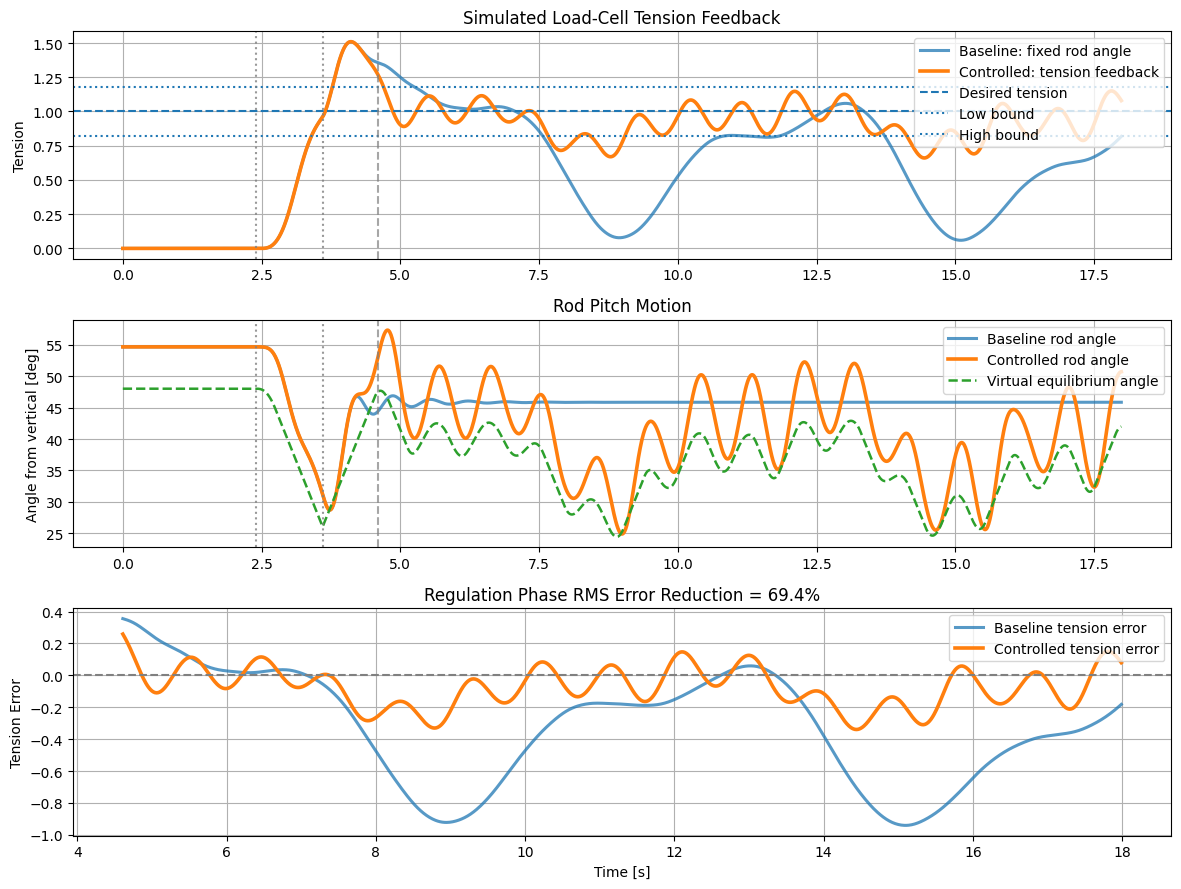

In [ ]:
def compute_metrics(res_base, res_ctrl):
    reg_start = BITE_TIME + HOOK_DURATION + 1.0

    mask_b = res_base["t"] > reg_start
    mask_c = res_ctrl["t"] > reg_start

    err_b = res_base["T_filtered"][mask_b] - T_DESIRED
    err_c = res_ctrl["T_filtered"][mask_c] - T_DESIRED

    rms_b = np.sqrt(np.mean(err_b**2))
    rms_c = np.sqrt(np.mean(err_c**2))

    improvement = (1.0 - rms_c / rms_b) * 100.0

    return rms_b, rms_c, improvement, reg_start


rms_b, rms_c, improvement, reg_start = compute_metrics(res_base, res_ctrl)

print(f"Baseline RMS tension error:   {rms_b:.3f}")
print(f"Controlled RMS tension error: {rms_c:.3f}")
print(f"Error reduction:              {improvement:.1f}%")

plt.figure(figsize=(12, 9))

# 1. Tension comparison
plt.subplot(3, 1, 1)
plt.plot(res_base["t"], res_base["T_filtered"],
         label="Baseline: fixed rod angle", linewidth=2.2, alpha=0.75)
plt.plot(res_ctrl["t"], res_ctrl["T_filtered"],
         label="Controlled: tension feedback", linewidth=2.6)
plt.axhline(T_DESIRED, linestyle="--", label="Desired tension")
plt.axhline(T_LOW, linestyle=":", label="Low bound")
plt.axhline(T_HIGH, linestyle=":", label="High bound")
plt.axvline(BITE_TIME, linestyle=":", color="gray", alpha=0.8)
plt.axvline(BITE_TIME + HOOK_DURATION, linestyle=":", color="gray", alpha=0.8)
plt.axvline(reg_start, linestyle="--", color="gray", alpha=0.7)
plt.ylabel("Tension")
plt.title("Simulated Load-Cell Tension Feedback")
plt.legend(loc="upper right")
plt.grid(True)

# 2. Rod angle
plt.subplot(3, 1, 2)
plt.plot(res_base["t"], res_base["q"],
         label="Baseline rod angle", linewidth=2.2, alpha=0.75)
plt.plot(res_ctrl["t"], res_ctrl["q"],
         label="Controlled rod angle", linewidth=2.6)
plt.plot(res_ctrl["t"], res_ctrl["q_eq"],
         "--", label="Virtual equilibrium angle", linewidth=1.8)
plt.axvline(BITE_TIME, linestyle=":", color="gray", alpha=0.8)
plt.axvline(BITE_TIME + HOOK_DURATION, linestyle=":", color="gray", alpha=0.8)
plt.axvline(reg_start, linestyle="--", color="gray", alpha=0.7)
plt.ylabel("Angle from vertical [deg]")
plt.title("Rod Pitch Motion")
plt.legend(loc="upper right")
plt.grid(True)

# 3. Regulation-phase tension error only
plt.subplot(3, 1, 3)
mask_b = res_base["t"] > reg_start
mask_c = res_ctrl["t"] > reg_start

plt.plot(res_base["t"][mask_b],
         res_base["T_filtered"][mask_b] - T_DESIRED,
         label="Baseline tension error", linewidth=2.2, alpha=0.75)
plt.plot(res_ctrl["t"][mask_c],
         res_ctrl["T_filtered"][mask_c] - T_DESIRED,
         label="Controlled tension error", linewidth=2.6)
plt.axhline(0, linestyle="--", color="gray")
plt.ylabel("Tension Error")
plt.xlabel("Time [s]")
plt.title(f"Regulation Phase RMS Error Reduction = {improvement:.1f}%")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
plt.show()